In [1]:
import sys
import sklearn
print("Python version:", sys.version)
print("Scikit-learn version:", sklearn.__version__)

Python version: 3.13.12 | packaged by Anaconda, Inc. | (main, Feb 24 2026, 16:05:56) [MSC v.1942 64 bit (AMD64)]
Scikit-learn version: 1.8.0


In [2]:
import os
import tarfile
import urllib.request
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, StratifiedShuffleSplit
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OrdinalEncoder, OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

In [3]:
DOWNLOAD_URL = "https://raw.githubusercontent.com/ageron/handson-ml2/master/datasets/housing/housing.tgz"
HOUSING_PATH = os.path.join("datasets", "housing")

def load_housing_data(housing_path=HOUSING_PATH, url=DOWNLOAD_URL):
    os.makedirs(housing_path, exist_ok=True)
    tgz_path = os.path.join(housing_path, "housing.tgz")
    urllib.request.urlretrieve(url, tgz_path)
    with tarfile.open(tgz_path) as f:
        f.extractall(path=housing_path)
    csv_path = os.path.join(housing_path, "housing.csv")
    return pd.read_csv(csv_path)

housing = load_housing_data()
print("Data loaded! Shape:", housing.shape)

Data loaded! Shape: (20640, 10)


C:\Users\Mohamad\AppData\Local\Temp\ipykernel_22772\3273292107.py:9: DeprecationWarning: Python 3.14 will, by default, filter extracted tar archives and reject files or modify their metadata. Use the filter argument to control this behavior.
  f.extractall(path=housing_path)


In [4]:
print(housing.head())
print("\n")
print(housing.info())
print("\n")
print(housing["ocean_proximity"].value_counts())

   longitude  latitude  housing_median_age  total_rooms  total_bedrooms  \
0    -122.23     37.88                41.0        880.0           129.0   
1    -122.22     37.86                21.0       7099.0          1106.0   
2    -122.24     37.85                52.0       1467.0           190.0   
3    -122.25     37.85                52.0       1274.0           235.0   
4    -122.25     37.85                52.0       1627.0           280.0   

   population  households  median_income  median_house_value ocean_proximity  
0       322.0       126.0         8.3252            452600.0        NEAR BAY  
1      2401.0      1138.0         8.3014            358500.0        NEAR BAY  
2       496.0       177.0         7.2574            352100.0        NEAR BAY  
3       558.0       219.0         5.6431            341300.0        NEAR BAY  
4       565.0       259.0         3.8462            342200.0        NEAR BAY  


<class 'pandas.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data col

In [5]:
print(housing.describe())

          longitude      latitude  housing_median_age   total_rooms  \
count  20640.000000  20640.000000        20640.000000  20640.000000   
mean    -119.569704     35.631861           28.639486   2635.763081   
std        2.003532      2.135952           12.585558   2181.615252   
min     -124.350000     32.540000            1.000000      2.000000   
25%     -121.800000     33.930000           18.000000   1447.750000   
50%     -118.490000     34.260000           29.000000   2127.000000   
75%     -118.010000     37.710000           37.000000   3148.000000   
max     -114.310000     41.950000           52.000000  39320.000000   

       total_bedrooms    population    households  median_income  \
count    20433.000000  20640.000000  20640.000000   20640.000000   
mean       537.870553   1425.476744    499.539680       3.870671   
std        421.385070   1132.462122    382.329753       1.899822   
min          1.000000      3.000000      1.000000       0.499900   
25%        296.00000

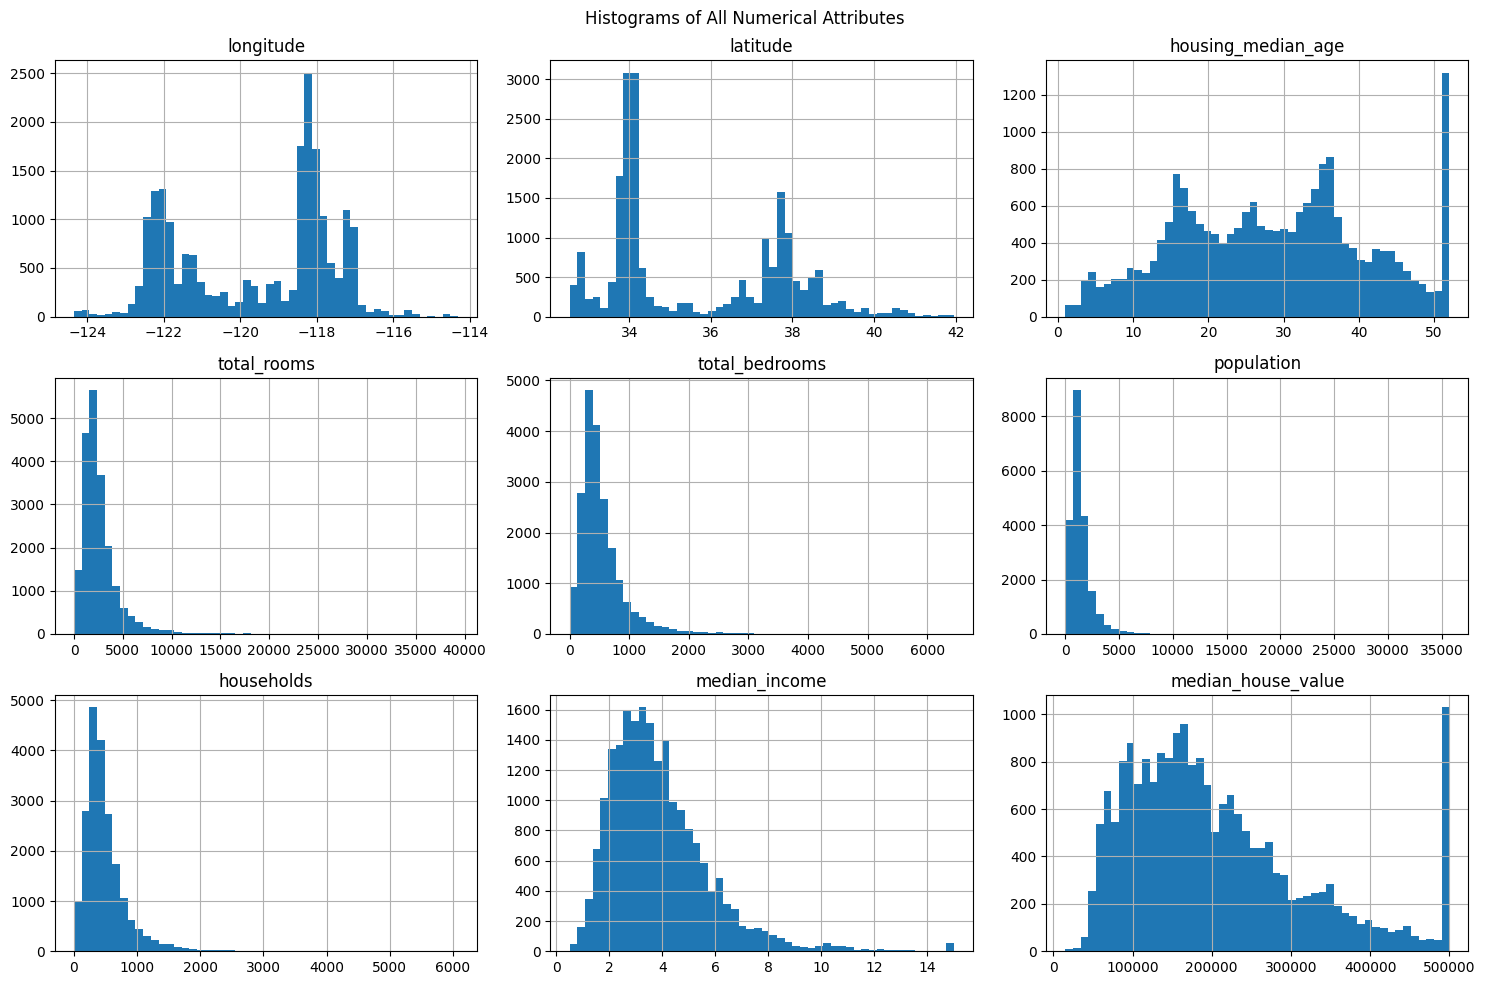

In [6]:
housing.hist(bins=50, figsize=(15, 10))
plt.suptitle("Histograms of All Numerical Attributes")
plt.tight_layout()
plt.savefig("histograms.png")
plt.show()

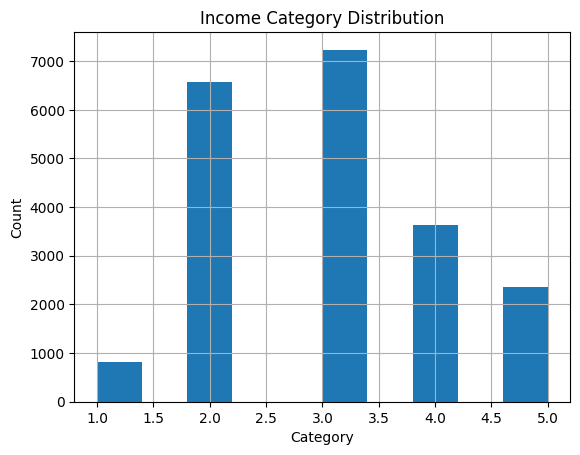

In [7]:
housing["income_cat"] = pd.cut(
    housing["median_income"],
    bins=[0, 1.5, 3.0, 4.5, 6.0, np.inf],
    labels=[1, 2, 3, 4, 5]
)
housing["income_cat"].hist()
plt.title("Income Category Distribution")
plt.xlabel("Category")
plt.ylabel("Count")
plt.show()

In [8]:
# Stratified split
split = StratifiedShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
for train_idx, test_idx in split.split(housing, housing["income_cat"]):
    strat_train = housing.iloc[train_idx]
    strat_test  = housing.iloc[test_idx]

# Random split for comparison
rand_train, rand_test = train_test_split(housing, test_size=0.2, random_state=42)

# Compare proportions
print("Full dataset:")
print(housing["income_cat"].value_counts() / len(housing))
print("\nStratified test set:")
print(strat_test["income_cat"].value_counts() / len(strat_test))
print("\nRandom test set:")
print(rand_test["income_cat"].value_counts() / len(rand_test))

Full dataset:
income_cat
3    0.350581
2    0.318847
4    0.176308
5    0.114438
1    0.039826
Name: count, dtype: float64

Stratified test set:
income_cat
3    0.350533
2    0.318798
4    0.176357
5    0.114341
1    0.039971
Name: count, dtype: float64

Random test set:
income_cat
3    0.358527
2    0.324370
4    0.167393
5    0.109496
1    0.040213
Name: count, dtype: float64


In [9]:
for df in (strat_train, strat_test):
    df.drop("income_cat", axis=1, inplace=True)

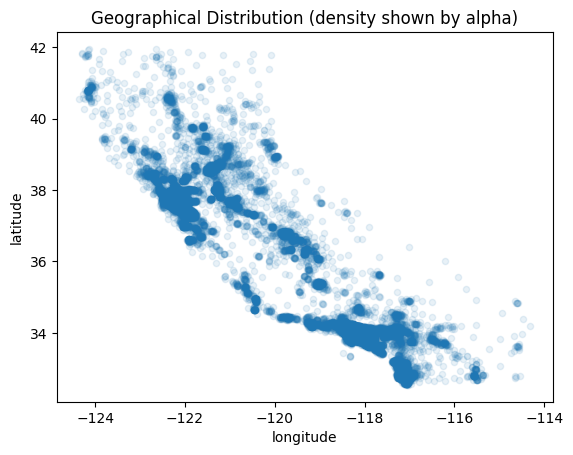

In [10]:
housing.plot(kind="scatter", x="longitude", y="latitude", alpha=0.1)
plt.title("Geographical Distribution (density shown by alpha)")
plt.savefig("geo_density.png")
plt.show()

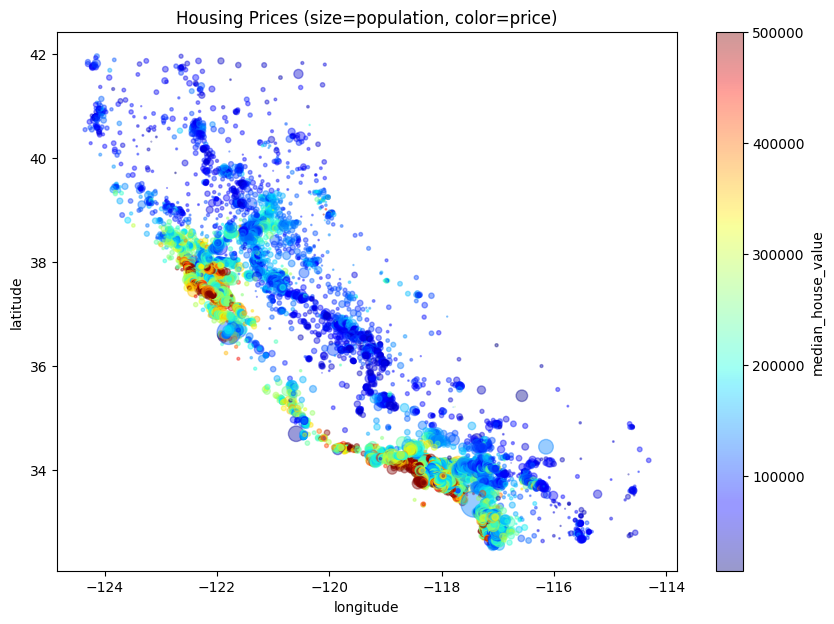

In [11]:
housing.plot(
    kind="scatter", x="longitude", y="latitude", alpha=0.4,
    s=housing["population"] / 100,      # circle size = population
    c="median_house_value",             # color = price
    cmap="jet", colorbar=True, figsize=(10, 7)
)
plt.title("Housing Prices (size=population, color=price)")
plt.savefig("geo_prices.png")
plt.show()

In [12]:
corr_matrix = housing.corr(numeric_only=True)
print(corr_matrix["median_house_value"].sort_values(ascending=False))

median_house_value    1.000000
median_income         0.688075
total_rooms           0.134153
housing_median_age    0.105623
households            0.065843
total_bedrooms        0.049686
population           -0.024650
longitude            -0.045967
latitude             -0.144160
Name: median_house_value, dtype: float64


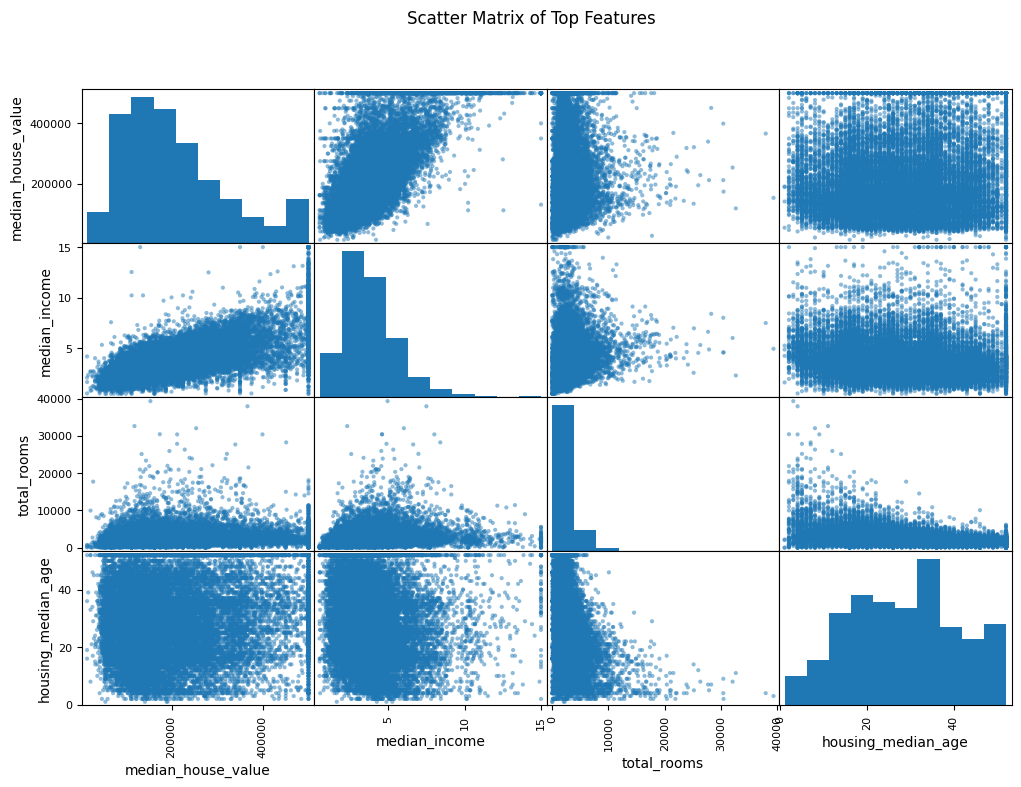

In [13]:
from pandas.plotting import scatter_matrix

top_features = ["median_house_value", "median_income", "total_rooms", "housing_median_age"]
scatter_matrix(housing[top_features], figsize=(12, 8))
plt.suptitle("Scatter Matrix of Top Features")
plt.savefig("scatter_matrix.png")
plt.show()

In [14]:
housing["rooms_per_household"]    = housing["total_rooms"]    / housing["households"]
housing["bedrooms_per_room"]      = housing["total_bedrooms"]  / housing["total_rooms"]
housing["population_per_household"] = housing["population"]   / housing["households"]

corr_matrix = housing.corr(numeric_only=True)
print(corr_matrix["median_house_value"].sort_values(ascending=False))

median_house_value          1.000000
median_income               0.688075
rooms_per_household         0.151948
total_rooms                 0.134153
housing_median_age          0.105623
households                  0.065843
total_bedrooms              0.049686
population_per_household   -0.023737
population                 -0.024650
longitude                  -0.045967
latitude                   -0.144160
bedrooms_per_room          -0.255880
Name: median_house_value, dtype: float64


In [15]:
housing = strat_train.drop("median_house_value", axis=1)
housing_labels = strat_train["median_house_value"].copy()

In [16]:
print("Missing values:\n", housing.isnull().sum())

imputer = SimpleImputer(strategy="median")
housing_num = housing.drop("ocean_proximity", axis=1)  # numbers only
imputer.fit(housing_num)

X = imputer.transform(housing_num)  # returns a numpy array
housing_tr = pd.DataFrame(X, columns=housing_num.columns, index=housing_num.index)
print("\nAfter imputing, missing values:\n", housing_tr.isnull().sum())

Missing values:
 longitude               0
latitude                0
housing_median_age      0
total_rooms             0
total_bedrooms        158
population              0
households              0
median_income           0
ocean_proximity         0
dtype: int64

After imputing, missing values:
 longitude             0
latitude              0
housing_median_age    0
total_rooms           0
total_bedrooms        0
population            0
households            0
median_income         0
dtype: int64


In [17]:
housing_cat = housing[["ocean_proximity"]]

# OrdinalEncoder — assigns integers (0,1,2...) implying an order that doesn't exist
ord_enc = OrdinalEncoder()
print("OrdinalEncoder sample:\n", ord_enc.fit_transform(housing_cat[:5]))

# OneHotEncoder — creates a binary column per category (no false order)
ohe = OneHotEncoder()
housing_cat_1hot = ohe.fit_transform(housing_cat)
print("\nOneHotEncoder categories:", ohe.categories_)
print("Shape:", housing_cat_1hot.shape)

OrdinalEncoder sample:
 [[1.]
 [2.]
 [1.]
 [2.]
 [0.]]

OneHotEncoder categories: [array(['<1H OCEAN', 'INLAND', 'ISLAND', 'NEAR BAY', 'NEAR OCEAN'],
      dtype=object)]
Shape: (16512, 5)


In [18]:
# Identify column types
num_attribs = list(housing_num.columns)
cat_attribs = ["ocean_proximity"]

# Pipeline for numerical: impute then scale
num_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler",  StandardScaler()),
])

# Full pipeline combining numerical and categorical
full_pipeline = ColumnTransformer([
    ("num", num_pipeline,            num_attribs),
    ("cat", OneHotEncoder(),         cat_attribs),
])

housing_prepared = full_pipeline.fit_transform(housing)
print("Output shape:", housing_prepared.shape)
print("First row sample:\n", housing_prepared[0])

Output shape: (16512, 13)
First row sample:
 [-0.94135046  1.34743822  0.02756357  0.58477745  0.64037127  0.73260236
  0.55628602 -0.8936472   0.          1.          0.          0.
  0.        ]
